<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); color: white; padding: 25px; text-align: center; border-radius: 12px; box-shadow: 0 4px 15px rgba(0,0,0,0.2); margin: 20px 0;">

# 使用YOLO模型进行预测和实时推理


</div>



<div style="background: linear-gradient(90deg, #11998e 0%, #38ef7d 100%); color: white; padding: 8px 20px; display: inline-block; border-radius: 4px; box-shadow: 0 2px 6px rgba(0,0,0,0.15); margin: 30px 0;">

## 1.单张照片目标检测预测

首次运行，确保右上角环境切换到了：YOLO

</div>





In [11]:
import torch
from ultralytics import YOLO

model = YOLO("./models/yolov10n.pt", task='detect')

device = 'cpu' if not torch.cuda.is_available() else 'cuda'
print(f"Using device: {device}")
model.to(device)

# Predict with the model
results = model(source="./test/bus.jpg", save=True, conf=0.05)

Using device: cuda

image 1/1 g:\\2025\\wk5\YOLO_stu\test\bus.jpg: 640x480 4 persons, 1 bus, 1 handbag, 1 skateboard, 22.2ms
Speed: 4.1ms preprocess, 22.2ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to G:\\2025\\wk5\YOLO_stu\runs\detect\predict-4


(np.float64(-0.5), np.float64(809.5), np.float64(1079.5), np.float64(-0.5))

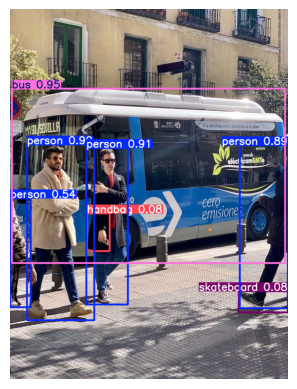

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(results[0].plot()[:,:,::-1])
plt.axis('off')


<div style="background: linear-gradient(90deg, #11998e 0%, #38ef7d 100%); color: white; padding: 8px 20px; display: inline-block; border-radius: 4px; box-shadow: 0 2px 6px rgba(0,0,0,0.15); margin: 30px 0;">

## 2.你的任务：用OpenCV打开摄像头，进行实时YOLO目标检测

额外要求：
- 按下键盘上的“q”键，关闭摄像头。
- 按下键盘上的“s”键，保存当前画面到文件夹下。

</div>






实时检测开始：使用摄像头索引 0，按 q 退出，按 s 保存当前检测画面。
已退出实时检测。


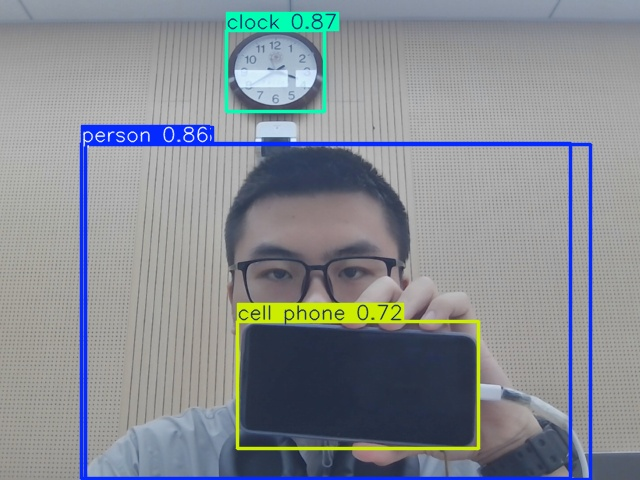

In [1]:
import time
from datetime import datetime
from pathlib import Path

import cv2
import torch
from IPython.display import clear_output, display
from PIL import Image
from ultralytics import YOLO

if 'model' not in globals():
    model = YOLO('./models/yolov10n.pt', task='detect')

if 'device' not in globals():
    device = 'cpu' if not torch.cuda.is_available() else 'cuda'

model.to(device)
save_dir = Path('./webcam_captures')
save_dir.mkdir(parents=True, exist_ok=True)

def open_available_camera(max_index=2):
    backend_candidates = [cv2.CAP_ANY]
    if hasattr(cv2, 'CAP_DSHOW'):
        backend_candidates.append(cv2.CAP_DSHOW)
    if hasattr(cv2, 'CAP_MSMF'):
        backend_candidates.append(cv2.CAP_MSMF)

    for camera_index in range(max_index + 1):
        for backend in backend_candidates:
            cap = cv2.VideoCapture(camera_index, backend)
            if cap.isOpened():
                return cap, camera_index, backend
            cap.release()

    return None, None, None

def highgui_available():
    try:
        cv2.namedWindow('highgui_test', cv2.WINDOW_NORMAL)
        cv2.destroyWindow('highgui_test')
        return True
    except cv2.error:
        return False

cap, camera_index, backend = open_available_camera()

if cap is None:
    print('未检测到可用摄像头。请检查以下几项后再重试：')
    print('1. 是否已在系统中允许 VS Code / Python 访问摄像头。')
    print('2. 是否有微信、QQ、浏览器或其他软件正在占用摄像头。')
    print('3. 如果是外接摄像头，是否已经正确连接。')
    print('4. 如仍失败，可把 0 改成 1 或 2，尝试其他摄像头编号。')
else:
    use_highgui = highgui_available()
    max_preview_frames = 60
    frame_counter = 0

    if use_highgui:
        print(f'实时检测开始：使用摄像头索引 {camera_index}，按 q 退出，按 s 保存当前检测画面。')
    else:
        print('当前环境不支持 cv2.imshow，已切换为 notebook 内联预览模式。')
        print(f'内联模式将自动预览 {max_preview_frames} 帧；如需提前结束，可停止该单元。')

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print('未能从摄像头读取画面，程序结束。')
                break

            results = model.predict(
                source=frame,
                conf=0.25,
                device=device,
                verbose=False
            )
            annotated_frame = results[0].plot()

            if use_highgui:
                cv2.imshow('YOLO Webcam Detection', annotated_frame)

                key = cv2.waitKey(1) & 0xFF
                if key == ord('q'):
                    print('已退出实时检测。')
                    break
                if key == ord('s'):
                    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
                    save_path = save_dir / f'webcam_detect_{timestamp}.jpg'
                    cv2.imwrite(str(save_path), annotated_frame)
                    print(f'已保存当前画面到: {save_path.resolve()}')
            else:
                annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
                clear_output(wait=True)
                display(Image.fromarray(annotated_frame_rgb))
                time.sleep(0.05)
                frame_counter += 1
                if frame_counter >= max_preview_frames:
                    print('内联预览已结束。若要继续观察，请重新运行本单元。')
                    break
    finally:
        cap.release()
        if use_highgui:
            try:
                cv2.destroyAllWindows()
            except cv2.error:
                pass
# 显示保存的图片
for img_path in save_dir.glob('webcam_detect_*.jpg'):
    display(Image.open(img_path))
    


<div style="background: linear-gradient(90deg, #11998e 0%, #38ef7d 100%); color: white; padding: 8px 20px; display: inline-block; border-radius: 4px; box-shadow: 0 2px 6px rgba(0,0,0,0.15); margin: 30px 0;">

## 3.迁移训练——用YOLO训练自己的数据集（Drink_dataset)


</div>





### 3.1 本节学习目标与观察任务

这一部分不只是“把模型训出来”，而是要学会回答下面 3 个问题：

1. 训练过程中，模型的定位能力和分类能力是不是在逐步变好？
2. 训练结束后，哪些类别学得比较稳定，哪些类别还容易混淆？
3. 把最佳权重拿去预测新图片时，模型到底是“框得准”，还是“分类准”，还是两者都还有问题？

建议边运行边记录：

- 第 1 类记录：训练曲线是否整体向好。
- 第 2 类记录：验证集样例里，模型更常见的问题是漏检、错检还是框偏移。
- 第 3 类记录：对饮料外观相似的类别，模型是否容易混淆。

In [1]:
import torch
from ultralytics import YOLO

model = YOLO('./models/yolov10n.pt')

device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model.train(
    data='drink.yaml',
    epochs=3,
    imgsz=640,
    batch=16,
    device=device,
    augment=True,
    workers=8
)

Using device: 0
Ultralytics 8.4.45  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=drink.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./models/yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000267B2828230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,   

#### 💡训练进行时，看什么才算“有效观察”？

训练跑起来后，不要只盯着进度条。更有价值的观察有两类：

- 过程观察：loss 是否整体下降，指标是否大体提升，而不是某一轮偶然变好。
- 结果观察：验证图中，模型是不是已经能把大多数目标框出来，并且类别大体正确。

如果发现 loss 在降，但验证图效果没有明显改善，就说明“数值变好”还没有完全转化成“视觉结果变好”，这时就要继续检查数据、类别差异和标注质量。

### 3.2 训练结果怎么看？

训练完成后，不要只看“有没有跑完”，还要学会从结果图中判断模型是否真的在变好。

这一部分重点看四类信息：

1. `results.png`：训练集和验证集的损失是否整体下降，`mAP50` 与 `mAP50-95` 是否逐步上升。
2. `BoxPR_curve.png`：不同类别在查准率与查全率之间的平衡情况。
3. `BoxF1_curve.png`：当置信度阈值变化时，模型整体效果在哪个区间最好。
4. `confusion_matrix_normalized.png`：哪些类别容易混淆，哪些类别已经比较稳定。

先观察，再下结论。这比只记住一个最终分数更重要。

#### 3.2.1 用案例方式观察训练结果

下面这组图片不要当成“训练自动生成的附件”，而要当成 6 个分析案例来读：

**案例 1：整体训练曲线 `results.png`**

- 先看训练损失和验证损失是否整体下降。
- 再看 `mAP50` 和 `mAP50-95` 是否逐步上升。
- 如果训练损失持续下降，但验证损失不降反升，通常要警惕过拟合。

**案例 2：Precision-Recall 曲线 `BoxPR_curve.png`**

- 曲线越靠近右上角，说明模型越能兼顾查准率和查全率。
- 如果某个类别曲线明显偏低，说明这个类别更难识别，可能和样本量、遮挡、外观相似度有关。

**案例 3：F1-Confidence 曲线 `BoxF1_curve.png`**

- 峰值附近通常是比较合适的置信度阈值区间。
- 如果阈值太低，误检会变多；如果阈值太高，漏检会增加。

**案例 4：归一化混淆矩阵 `confusion_matrix_normalized.png`**

- 对角线越亮，说明该类别越稳定。
- 非对角位置如果数值偏高，说明两个类别容易混淆。
- 对饮料数据集，可以重点观察外观接近的类别是否互相误判。

**案例 5 和案例 6：验证集预测图 `val_batch*_pred.jpg`**

- 观察模型是“漏掉了目标”，还是“框偏了”，还是“类别判断错了”。
- 如果大目标检测稳定、小目标经常漏掉，通常说明模型对小目标不够敏感。
- 如果框出来了但标签错了，要优先检查类别间差异和训练样本分布。

建议同学们按“先整体趋势、再阈值权衡、再类别混淆、最后看具体样例”的顺序分析，而不是只报一个最终分数。

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

runs_dir = Path("./runs/detect")
train_run_candidates = sorted(
    [path for path in runs_dir.glob("train*") if path.is_dir()],
    key=lambda path: path.stat().st_mtime
)

if not train_run_candidates:
    raise FileNotFoundError("没有找到训练结果目录，请先运行上一单元完成训练。")

train_run_dir = train_run_candidates[-1]
results_path = train_run_dir / "results.csv"
results_df = pd.read_csv(results_path)

final_row = results_df.iloc[-1]
best_row = results_df.loc[results_df["metrics/mAP50-95(B)"].idxmax()]

print(f"当前展示的训练结果目录: {train_run_dir.resolve()}")
print("=" * 60)
print(f"最终 epoch: {int(final_row['epoch'])}")
print(f"最佳 epoch（按 mAP50-95 选取）: {int(best_row['epoch'])}")
print(f"最终 Precision: {final_row['metrics/precision(B)']:.3f}")
print(f"最终 Recall: {final_row['metrics/recall(B)']:.3f}")
print(f"最终 mAP@0.5: {final_row['metrics/mAP50(B)']:.3f}")
print(f"最终 mAP@0.5:0.95: {final_row['metrics/mAP50-95(B)']:.3f}")
print(f"train box loss: {results_df.iloc[0]['train/box_loss']:.3f} -> {final_row['train/box_loss']:.3f}")
print(f"val box loss: {results_df.iloc[0]['val/box_loss']:.3f} -> {final_row['val/box_loss']:.3f}")

case_images = [
    ("results.png", "案例 1：整体训练曲线"),
    ("BoxPR_curve.png", "案例 2：Precision-Recall 曲线"),
    ("BoxF1_curve.png", "案例 3：F1-Confidence 曲线"),
    ("confusion_matrix_normalized.png", "案例 4：归一化混淆矩阵"),
    ("val_batch0_pred.jpg", "案例 5：验证集检测效果示例 1"),
    ("val_batch1_pred.jpg", "案例 6：验证集检测效果示例 2"),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
for ax, (file_name, title) in zip(axes.flat, case_images):
    image = Image.open(train_run_dir / file_name)
    ax.imshow(image)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()

当前展示的训练结果目录: G:\学业\2025大一下\人工智能基础\wk5\YOLO_stu\runs\detect\train-9
最终 epoch: 3
最佳 epoch（按 mAP50-95 选取）: 3
最终 Precision: 0.019
最终 Recall: 0.929
最终 mAP@0.5: 0.220
最终 mAP@0.5:0.95: 0.197
train box loss: 0.514 -> 0.464
val box loss: 0.278 -> 0.306


<Figure size 1600x1800 with 6 Axes>

### 3.3 如何分析测试结果？

看到预测图后，建议按下面顺序观察：

1. 先看有没有漏检。图片里本来有的目标，如果完全没有框出来，就是漏检。
2. 再看类别是否判断正确。框出来了但标签错了，说明分类区分还不够稳。
3. 最后看框的位置是否贴合目标。类别对了但框偏得很厉害，说明定位能力还可以继续提升。

下面的表格把每个检测框的类别、置信度和坐标列出来，方便把“直观看图”变成“结合数字分析”。

💡**特别提醒**：

- 高置信度不一定代表绝对正确，但通常说明模型更有把握。
- 低置信度框要结合画面内容判断，既可能是真目标较难，也可能是误检。
- 如果同类目标里只有大目标置信度高、小目标置信度明显低，往往说明模型对小目标还不够敏感。

In [6]:
from ultralytics import YOLO

model_path = train_run_dir / "weights" / "best.pt"
print(f"加载最佳权重: {model_path.resolve()}")
model = YOLO(str(model_path))
model.info()

加载最佳权重: G:\学业\2025大一下\人工智能基础\wk5\YOLO_stu\runs\detect\train-9\weights\best.pt
YOLOv10n summary: 224 layers, 2,710,940 parameters, 0 gradients, 8.4 GFLOPs


(224, 2710940, 0, 8.4123136)

In [7]:
#预测单张照片

result = model.predict(source="./test/wangzai.png",save_txt=True, imgsz=416, save_conf=True, save=True, conf=0.25)


image 1/1 g:\\2025\\wk5\YOLO_stu\test\wangzai.png: 416x384 (no detections), 22.6ms
Speed: 2.9ms preprocess, 22.6ms inference, 0.3ms postprocess per image at shape (1, 3, 416, 384)
Results saved to G:\\2025\\wk5\YOLO_stu\runs\detect\predict-3
0 label saved to G:\\2025\\wk5\YOLO_stu\runs\detect\predict-3\labels


In [8]:
# 结果展示
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# 从预测结果中提取检测信息并构建 DataFrame
boxes = result[0].boxes
summary_rows = []

for box in boxes:
    cls_id = int(box.cls.item())
    conf = float(box.conf.item())
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    summary_rows.append({
        "类别": model.names[cls_id],
        "置信度": round(conf, 3),
        "xmin": round(x1, 1),
        "ymin": round(y1, 1),
        "xmax": round(x2, 1),
        "ymax": round(y2, 1),
        "框宽": round(x2 - x1, 1),
        "框高": round(y2 - y1, 1),
    })

detection_summary = pd.DataFrame(summary_rows).sort_values(by="置信度", ascending=False).reset_index(drop=True)
display(detection_summary)

annotated_frame = result[0].plot()

# 将 BGR 转换为 RGB（YOLO 输出是 BGR 格式）
annotated_frame_rgb = annotated_frame[..., ::-1]

# 使用 matplotlib 显示
plt.figure(figsize=(12, 8))
plt.imshow(annotated_frame_rgb)
plt.axis('off')
plt.title('YOLO Detection Result')
plt.tight_layout()
plt.show()





KeyError: '置信度'